# Finite-volume 2D debug

Debug the transport solver on a **2D slice (x-z)** before trusting it in 3D.

In 2D a wrong upwind sign or a wrong boundary is something you can *see* - a plume drifting the wrong way, a negative value, a stripe at the edge. In 3D the same bug only looks like "odd numbers".

The grid is one cell thick in `y`, so the array is still `[z, y, x]` and the same code path runs as in the full model.

In [1]:
import importlib.util
import sys
from pathlib import Path

import numpy as np

# src/03_transport.py is not a valid module name, and this notebook may be run
# from any directory, so load it by path instead of with an import statement.
ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

spec = importlib.util.spec_from_file_location(
    "transport_module", ROOT / "src" / "03_transport.py"
)
transport = importlib.util.module_from_spec(spec)
sys.modules["transport_module"] = transport
spec.loader.exec_module(transport)

print("loaded", ROOT / "src" / "03_transport.py")

loaded /Users/jasonnguyen/AI-harness/ai-harness/projects/ie402-voxel-air-dispersion/src/03_transport.py


In [2]:
# ---- grid: one cell thick in y, so this is an x-z slice -------------------
DZ, DY, DX = 2.0, 5.0, 5.0
nz, ny, nx = 50, 1, 100
shape = (nz, ny, nx)

# ---- a building in the middle of the slice --------------------------------
solid = np.zeros(shape, dtype=bool)
solid[0:10, :, 40:50] = True   # 20 m tall, 50 m wide

# ---- uniform wind along +x, zero inside the building ----------------------
u = np.full(shape, 3.0)
u[solid] = 0.0
velocity = (np.zeros(shape), np.zeros(shape), u)

# ---- a road source upwind of the building ---------------------------------
source = np.zeros(shape)
source[0, :, 20] = 1.0

K = 1.0
dt = transport.cfl_time_step(velocity, K, dz_m=DZ, dy_m=DY, dx_m=DX, courant=0.5)

print(f"dt    = {dt:.3f} s")
print(f"Cr    = {transport.courant_number(velocity, dt, dz_m=DZ, dy_m=DY, dx_m=DX):.3f}")
print(f"K_num = {transport.numerical_diffusion(3.0, DX, 0.5):.2f} m2/s   vs   K = {K} m2/s")

dt    = 0.758 s
Cr    = 0.455
K_num = 3.75 m2/s   vs   K = 1.0 m2/s


In [3]:
c = np.zeros(shape)

for step in range(600):
    c = transport.transport_step(
        c, velocity, source, K, dt,
        dz_m=DZ, dy_m=DY, dx_m=DX, solid=solid,
    )

    # Both must hold at EVERY step. Fail loudly rather than silently.
    assert c.min() >= 0.0, f"negative concentration at step {step}"
    assert c[solid].sum() == 0.0, f"mass inside a building at step {step}"

print(f"min C = {c.min():.3e}    max C = {c.max():.3e}")

min C = 0.000e+00    max C = 2.579e+01


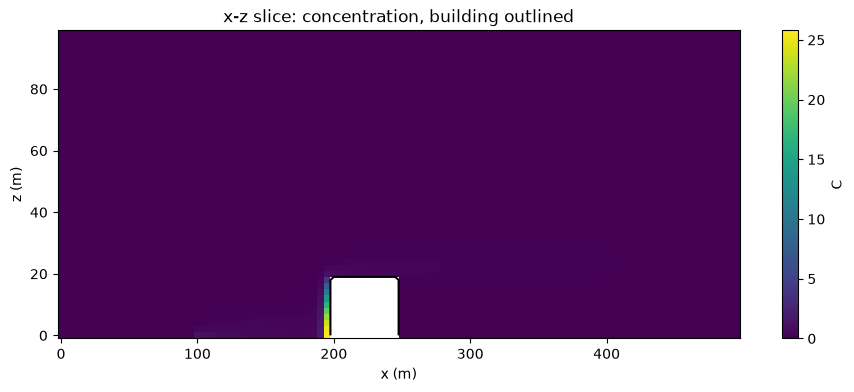

In [4]:
import matplotlib.pyplot as plt

field = np.ma.masked_where(solid[:, 0, :], c[:, 0, :])

fig, ax = plt.subplots(figsize=(11, 4))
mesh = ax.pcolormesh(
    np.arange(nx) * DX, np.arange(nz) * DZ, field, shading="auto"
)
ax.contour(
    np.arange(nx) * DX, np.arange(nz) * DZ, solid[:, 0, :],
    levels=[0.5], colors="k", linewidths=1.5,
)
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_title("x-z slice: concentration, building outlined")
fig.colorbar(mesh, ax=ax, label="C")
plt.show()

# What to look for:
#   plume drifts RIGHT (+x)               -> upwind sign is correct
#   nothing inside the building outline   -> wall flux is zero
#   no speckle or checkerboard            -> the scheme is bounded
#   plume wider than expected             -> that is K_num, printed above